In [1]:

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:

import shutil, os

DRIVE_ZIP_PATH = '/content/drive/MyDrive/beyond-visible-spectrum-ai-for-agriculture-2024.zip'
LOCAL_ZIP_PATH = '/content/dataset.zip'

shutil.copy(DRIVE_ZIP_PATH, LOCAL_ZIP_PATH)
print("Copied. Size (MB):", os.path.getsize(LOCAL_ZIP_PATH) / 1e6)

Copied. Size (MB): 946.572868


In [3]:

import zipfile

LOCAL_DATA_ROOT = '/content/data'
os.makedirs(LOCAL_DATA_ROOT, exist_ok=True)

with zipfile.ZipFile(LOCAL_ZIP_PATH, 'r') as zf:
    zf.extractall(LOCAL_DATA_ROOT)

print("Extracted. Top-level contents:", os.listdir(LOCAL_DATA_ROOT))

Extracted. Top-level contents: ['beyond-visible-spectrum-ai-for-agriculture-2024']


In [ ]:

for root, dirs, files in os.walk(LOCAL_DATA_ROOT):
    if files:
        print(root, '->', len(files), 'files (e.g.', files[0], ')')
        continue

/content/data/beyond-visible-spectrum-ai-for-agriculture-2024/ICPR01/kaggle/2 -> 690 files (e.g. 0508_be43d680679644698635e70ccd00cc71.pt )
/content/data/beyond-visible-spectrum-ai-for-agriculture-2024/ICPR01/kaggle/evaluation -> 83 files (e.g. 0503_49857bd87139473d89663a246ca8566b.pt )
/content/data/beyond-visible-spectrum-ai-for-agriculture-2024/ICPR01/kaggle/1 -> 1006 files (e.g. 0503_a22c61d79d8f4ad7b4892ab79d49ac00.pt )
/content/data/beyond-visible-spectrum-ai-for-agriculture-2024/archive/train/Other -> 200 files (e.g. hyper (39).tif )
/content/data/beyond-visible-spectrum-ai-for-agriculture-2024/archive/train/Health -> 200 files (e.g. hyper (39).tif )
/content/data/beyond-visible-spectrum-ai-for-agriculture-2024/archive/train/Rust -> 200 files (e.g. hyper (39).tif )
/content/data/beyond-visible-spectrum-ai-for-agriculture-2024/archive/val/val -> 300 files (e.g. 355.tif )


In [4]:
import tifffile as tiff
import numpy as np
import os, glob

ROOT = '/content/data/beyond-visible-spectrum-ai-for-agriculture-2024/archive'

for cls in ['Health', 'Rust', 'Other']:
    files = glob.glob(os.path.join(ROOT, 'train', cls, '*.tif'))
    sample_path = files[0]
    arr = tiff.imread(sample_path)
    print(f"--- {cls} ({len(files)} files) ---")
    print("file:", os.path.basename(sample_path))
    print("shape:", arr.shape)
    print("dtype:", arr.dtype)
    print("min / max:", arr.min(), arr.max())
    if arr.dtype.kind == 'f':
        print("has NaNs:", np.isnan(arr).any())
    print()


val_files = glob.glob(os.path.join(ROOT, 'val', 'val', '*.tif'))
val_arr = tiff.imread(val_files[0])
print("--- val sample ---")
print("file:", os.path.basename(val_files[0]))
print("shape:", val_arr.shape, "dtype:", val_arr.dtype)

--- Health (200 files) ---
file: hyper (39).tif
shape: (64, 64, 125)
dtype: uint16
min / max: 161 4546

--- Rust (200 files) ---
file: hyper (39).tif
shape: (64, 64, 125)
dtype: uint16
min / max: 48 5892

--- Other (200 files) ---
file: hyper (39).tif
shape: (64, 64, 125)
dtype: uint16
min / max: 455 2654

--- val sample ---
file: 355.tif
shape: (64, 64, 125) dtype: uint16


In [6]:
import tifffile as tiff
import numpy as np
import os, glob

ROOT = '/content/data/beyond-visible-spectrum-ai-for-agriculture-2024/archive'

def check_padding_band(filepath):
    arr = tiff.imread(filepath)
    if arr.shape[-1] == 126:
        last_band = arr[:, :, 125]
        is_sentinel = np.all(last_band == 65535)
        return arr.shape, is_sentinel
    return arr.shape, None

print("=== Verifying padding-band assumption across ALL files ===")
all_files = []
for cls in ['Health', 'Rust', 'Other']:
    all_files += [(f, cls) for f in glob.glob(os.path.join(ROOT, 'train', cls, '*.tif'))]
all_files += [(f, 'val') for f in glob.glob(os.path.join(ROOT, 'val', 'val', '*.tif'))]

bad_files = []
count_126 = 0
count_125 = 0
for f, cls in all_files:
    shape, is_sentinel = check_padding_band(f)
    if shape[-1] == 126:
        count_126 += 1
        if not is_sentinel:
            bad_files.append((f, cls, shape))
    elif shape[-1] == 125:
        count_125 += 1
    else:
        bad_files.append((f, cls, shape))

print(f"Total files checked: {len(all_files)}")
print(f"Files with 126 bands (padding confirmed sentinel): {count_126}")
print(f"Files with 125 bands (no padding): {count_125}")
print(f"Files where assumption FAILS or shape is unexpected: {len(bad_files)}")
if bad_files:
    print("First few problem files:", bad_files[:5])

=== Verifying padding-band assumption across ALL files ===
Total files checked: 900
Files with 126 bands (padding confirmed sentinel): 159
Files with 125 bands (no padding): 741
Files where assumption FAILS or shape is unexpected: 5
First few problem files: [('/content/data/beyond-visible-spectrum-ai-for-agriculture-2024/archive/train/Health/hyper (168).tif', 'Health', (64, 64, 126)), ('/content/data/beyond-visible-spectrum-ai-for-agriculture-2024/archive/train/Health/hyper (34).tif', 'Health', (64, 64, 126)), ('/content/data/beyond-visible-spectrum-ai-for-agriculture-2024/archive/train/Health/hyper (23).tif', 'Health', (64, 64, 126)), ('/content/data/beyond-visible-spectrum-ai-for-agriculture-2024/archive/train/Other/hyper (147).tif', 'Other', (64, 64, 126)), ('/content/data/beyond-visible-spectrum-ai-for-agriculture-2024/archive/train/Other/hyper (122).tif', 'Other', (64, 64, 126))]


In [7]:
import tifffile as tiff
import numpy as np

problem_files = [
    '/content/data/beyond-visible-spectrum-ai-for-agriculture-2024/archive/train/Health/hyper (23).tif',
    '/content/data/beyond-visible-spectrum-ai-for-agriculture-2024/archive/train/Health/hyper (168).tif',
    '/content/data/beyond-visible-spectrum-ai-for-agriculture-2024/archive/train/Health/hyper (34).tif',
    '/content/data/beyond-visible-spectrum-ai-for-agriculture-2024/archive/train/Other/hyper (147).tif',
    '/content/data/beyond-visible-spectrum-ai-for-agriculture-2024/archive/train/Other/hyper (122).tif',
]

for f in problem_files:
    arr = tiff.imread(f)
    last_band = arr[:, :, 125]
    second_last = arr[:, :, 124]
    print(f"--- {f.split('/')[-1]} ---")
    print("band 125: min={}, max={}, mean={:.1f}, unique_vals={}".format(
        last_band.min(), last_band.max(), last_band.mean(), len(np.unique(last_band))))
    print("band 124 (for comparison): min={}, max={}, mean={:.1f}".format(
        second_last.min(), second_last.max(), second_last.mean()))
    print()

--- hyper (23).tif ---
band 125: min=0, max=0, mean=0.0, unique_vals=1
band 124 (for comparison): min=0, max=0, mean=0.0

--- hyper (168).tif ---
band 125: min=0, max=65535, mean=63231.0, unique_vals=2
band 124 (for comparison): min=0, max=7085, mean=3545.5

--- hyper (34).tif ---
band 125: min=0, max=0, mean=0.0, unique_vals=1
band 124 (for comparison): min=0, max=0, mean=0.0

--- hyper (147).tif ---
band 125: min=0, max=65535, mean=4095.9, unique_vals=2
band 124 (for comparison): min=0, max=3319, mean=176.3

--- hyper (122).tif ---
band 125: min=0, max=0, mean=0.0, unique_vals=1
band 124 (for comparison): min=0, max=0, mean=0.0



In [8]:
import tifffile as tiff
import numpy as np

problem_files = [
    '/content/data/beyond-visible-spectrum-ai-for-agriculture-2024/archive/train/Health/hyper (23).tif',
    '/content/data/beyond-visible-spectrum-ai-for-agriculture-2024/archive/train/Health/hyper (168).tif',
    '/content/data/beyond-visible-spectrum-ai-for-agriculture-2024/archive/train/Health/hyper (34).tif',
    '/content/data/beyond-visible-spectrum-ai-for-agriculture-2024/archive/train/Other/hyper (147).tif',
    '/content/data/beyond-visible-spectrum-ai-for-agriculture-2024/archive/train/Other/hyper (122).tif',
]

for f in problem_files:
    arr = tiff.imread(f)
    print(f"--- {f.split('/')[-1]} ---")

    for b in range(110, 126):
        band = arr[:, :, b]
        print(f"  band {b}: min={band.min()}, max={band.max()}, mean={band.mean():.1f}, unique={len(np.unique(band))}")
    print()



--- hyper (23).tif ---
  band 110: min=0, max=0, mean=0.0, unique=1
  band 111: min=0, max=0, mean=0.0, unique=1
  band 112: min=0, max=0, mean=0.0, unique=1
  band 113: min=0, max=0, mean=0.0, unique=1
  band 114: min=0, max=0, mean=0.0, unique=1
  band 115: min=0, max=0, mean=0.0, unique=1
  band 116: min=0, max=0, mean=0.0, unique=1
  band 117: min=0, max=0, mean=0.0, unique=1
  band 118: min=0, max=0, mean=0.0, unique=1
  band 119: min=0, max=0, mean=0.0, unique=1
  band 120: min=0, max=0, mean=0.0, unique=1
  band 121: min=0, max=0, mean=0.0, unique=1
  band 122: min=0, max=0, mean=0.0, unique=1
  band 123: min=0, max=0, mean=0.0, unique=1
  band 124: min=0, max=0, mean=0.0, unique=1
  band 125: min=0, max=0, mean=0.0, unique=1

--- hyper (168).tif ---
  band 110: min=0, max=8065, mean=4176.8, unique=1343
  band 111: min=0, max=8157, mean=4150.6, unique=1327
  band 112: min=0, max=8152, mean=4154.7, unique=1350
  band 113: min=0, max=8057, mean=4175.6, unique=1376
  band 114: min=

In [9]:
import os, glob
import numpy as np
import tifffile as tiff
from sklearn.model_selection import train_test_split

ROOT = '/content/data/beyond-visible-spectrum-ai-for-agriculture-2024/archive'
CLASSES = ['Health', 'Rust', 'Other']  # index 0,1,2 -> label
LABEL_MAP = {c: i for i, c in enumerate(CLASSES)}

CORRUPTED_FILES = {
    'hyper (23).tif', 'hyper (34).tif', 'hyper (122).tif'
}

# Step 1: full file list, excluding corrupted files
all_samples = []  # list of (filepath, label)
for cls in CLASSES:
    files = glob.glob(os.path.join(ROOT, 'train', cls, '*.tif'))
    for f in files:
        if os.path.basename(f) in CORRUPTED_FILES:
            continue
        all_samples.append((f, LABEL_MAP[cls]))

print("Total usable samples:", len(all_samples))
for cls, idx in LABEL_MAP.items():
    n = sum(1 for _, l in all_samples if l == idx)
    print(f"  {cls}: {n}")

# Step 2: Stratified 70/15/15 split
paths = [s[0] for s in all_samples]
labels = [s[1] for s in all_samples]

train_paths, temp_paths, train_labels, temp_labels = train_test_split(
    paths, labels, test_size=0.30, stratify=labels, random_state=42
)
val_paths, test_paths, val_labels, test_labels = train_test_split(
    temp_paths, temp_labels, test_size=0.50, stratify=temp_labels, random_state=42
)

print(f"\nTrain: {len(train_paths)} | Val: {len(val_paths)} | Test: {len(test_paths)}")

Total usable samples: 591
  Health: 197
  Rust: 197
  Other: 197

Train: 413 | Val: 89 | Test: 89


In [10]:
# Step 3: e per-band mean/std from TRAINING split only
def load_and_clean(filepath):
    """Load a .tif, drop band 125 if present, return (64,64,125) float32 array."""
    arr = tiff.imread(filepath).astype(np.float32)
    if arr.shape[-1] == 126:
        arr = arr[:, :, :125]
    return arr

# Accumulate sum and sum-of-squares per band across all training pixels
n_bands = 125
band_sum = np.zeros(n_bands, dtype=np.float64)
band_sq_sum = np.zeros(n_bands, dtype=np.float64)
pixel_count = 0

for fp in train_paths:
    arr = load_and_clean(fp)          # (64, 64, 125)
    band_sum += arr.sum(axis=(0, 1))
    band_sq_sum += (arr.astype(np.float64) ** 2).sum(axis=(0, 1))
    pixel_count += arr.shape[0] * arr.shape[1]

band_mean = band_sum / pixel_count
band_var = (band_sq_sum / pixel_count) - (band_mean ** 2)
band_std = np.sqrt(np.maximum(band_var, 1e-8))  # avoid div-by-zero on flat bands

print("band_mean shape:", band_mean.shape)
print("first 5 means:", band_mean[:5])
print("first 5 stds:", band_std[:5])
print("any zero/near-zero std bands?", np.sum(band_std < 1e-3))

band_mean shape: (125,)
first 5 means: [273.98741287 330.25763398 357.68582471 376.49445925 389.59922573]
first 5 stds: [338.89279959 358.62957687 362.114981   364.50986963 372.10494591]
any zero/near-zero std bands? 0


In [11]:

SAVE_DIR = '/content/drive/MyDrive/phytoguard_checkpoints'
os.makedirs(SAVE_DIR, exist_ok=True)

np.savez(
    os.path.join(SAVE_DIR, 'normalization_stats.npz'),
    mean=band_mean, std=band_std
)


np.savez(
    os.path.join(SAVE_DIR, 'data_split.npz'),
    train_paths=train_paths, train_labels=train_labels,
    val_paths=val_paths, val_labels=val_labels,
    test_paths=test_paths, test_labels=test_labels
)

print("Saved normalization stats and split to Drive.")

Saved normalization stats and split to Drive.


In [12]:
from sklearn.decomposition import IncrementalPCA
import tifffile as tiff
import numpy as np

def load_and_clean(filepath):
    arr = tiff.imread(filepath).astype(np.float32)
    if arr.shape[-1] == 126:
        arr = arr[:, :, :125]
    return arr

# Subsample pixels per image (using all 4096 pixels x 413 images = too much RAM at once).
# 500 random pixels/image still gives PCA plenty of signal to work with.
PIXELS_PER_IMAGE = 500
rng = np.random.default_rng(42)

pixel_samples = []
for fp in train_paths:
    arr = load_and_clean(fp)                         # (64, 64, 125)
    arr_norm = (arr - band_mean) / band_std           # z-score, same stats as before
    flat = arr_norm.reshape(-1, 125)                  # (4096, 125)
    idx = rng.choice(flat.shape[0], size=PIXELS_PER_IMAGE, replace=False)
    pixel_samples.append(flat[idx])

pixel_matrix = np.concatenate(pixel_samples, axis=0)  # (~206500, 125)
print("Pixel matrix for PCA fitting:", pixel_matrix.shape)

# Fit PCA
N_COMPONENTS = 15
pca = IncrementalPCA(n_components=N_COMPONENTS, batch_size=2048)
pca.fit(pixel_matrix)

print("Explained variance ratio per component:", pca.explained_variance_ratio_)
print("Cumulative explained variance:", np.cumsum(pca.explained_variance_ratio_))

Pixel matrix for PCA fitting: (206500, 125)
Explained variance ratio per component: [6.18351937e-01 3.73041391e-01 3.12108755e-03 2.44127309e-03
 8.30269180e-04 3.21825885e-04 2.55548674e-04 1.93469890e-04
 1.58006316e-04 1.07317246e-04 9.24001083e-05 7.18377415e-05
 6.26865123e-05 5.45848641e-05 3.67176687e-05]
Cumulative explained variance: [0.61835194 0.99139333 0.99451442 0.99695569 0.99778596 0.99810778
 0.99836333 0.9985568  0.99871481 0.99882213 0.99891453 0.99898636
 0.99904905 0.99910364 0.99914035]


In [13]:


import joblib

joblib.dump(pca, os.path.join(SAVE_DIR, 'pca_transform.pkl'))
print("Saved PCA transform to Drive.")

Saved PCA transform to Drive.


In [14]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
import numpy as np

# Reuse the same pixel_matrix from PCA fitting, but now we need per-pixel LABELS too
# (before only used the pixels themselves, unlabeled, for PCA)

pixel_samples = []
pixel_labels = []
for fp, lbl in zip(train_paths, train_labels):
    arr = load_and_clean(fp)
    arr_norm = (arr - band_mean) / band_std
    flat = arr_norm.reshape(-1, 125)
    idx = rng.choice(flat.shape[0], size=PIXELS_PER_IMAGE, replace=False)
    pixel_samples.append(flat[idx])
    pixel_labels.append(np.full(PIXELS_PER_IMAGE, lbl))

pixel_matrix_labeled = np.concatenate(pixel_samples, axis=0)   # (~206500, 125)
pixel_labels_flat = np.concatenate(pixel_labels, axis=0)       # (~206500,)

lda = LinearDiscriminantAnalysis(n_components=2)  # max = n_classes - 1 = 2
lda.fit(pixel_matrix_labeled, pixel_labels_flat)

print("LDA explained variance ratio (class separation captured):", lda.explained_variance_ratio_)

joblib.dump(lda, os.path.join(SAVE_DIR, 'lda_transform.pkl'))
print("Saved LDA transform to Drive.")

LDA explained variance ratio (class separation captured): [0.80922859 0.19077141]
Saved LDA transform to Drive.


In [15]:
# LDA space actually separate Health from Rust better than PCA did?
def per_image_lda_means(paths, labels, lda, band_mean, band_std):
    lda_means = []
    for fp, lbl in zip(paths, labels):
        arr = load_and_clean(fp)
        arr_norm = (arr - band_mean) / band_std
        flat = arr_norm.reshape(-1, 125)
        lda_vals = lda.transform(flat)
        lda_means.append((lda_vals.mean(axis=0), lbl))
    return lda_means

lda_results = per_image_lda_means(train_paths, train_labels, lda, band_mean, band_std)
health_lda = np.array([r[0] for r in lda_results if r[1] == 0])
rust_lda   = np.array([r[0] for r in lda_results if r[1] == 1])
other_lda  = np.array([r[0] for r in lda_results if r[1] == 2])

print("Health-vs-Rust mean abs diff (LDA space):", np.abs(health_lda.mean(0) - rust_lda.mean(0)).mean())
print("Health-vs-Other mean abs diff (LDA space):", np.abs(health_lda.mean(0) - other_lda.mean(0)).mean())
print("Rust-vs-Other mean abs diff (LDA space):", np.abs(rust_lda.mean(0) - other_lda.mean(0)).mean())

Health-vs-Rust mean abs diff (LDA space): 0.7885655191585407
Health-vs-Other mean abs diff (LDA space): 1.188495295516368
Rust-vs-Other mean abs diff (LDA space): 1.2274463953937975


In [17]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import numpy as np
import tifffile as tiff
import os
import joblib

In [18]:
class HyperspectralLDAPCADataset(Dataset):
    def __init__(self, filepaths, labels, band_mean, band_std, pca, lda, n_pca_components=5, augment=False):
        self.filepaths = filepaths
        self.labels = labels
        self.band_mean = band_mean.astype(np.float32)
        self.band_std = band_std.astype(np.float32)
        self.pca = pca
        self.lda = lda
        self.n_pca_components = n_pca_components
        self.augment = augment

    def __len__(self):
        return len(self.filepaths)

    def _load_and_clean(self, filepath):
        arr = tiff.imread(filepath).astype(np.float32)
        if arr.shape[-1] == 126:
            arr = arr[:, :, :125]
        return arr

    def _augment(self, arr):
        if np.random.rand() < 0.5:
            arr = np.flip(arr, axis=0)
        if np.random.rand() < 0.5:
            arr = np.flip(arr, axis=1)
        k = np.random.choice([0, 1, 2, 3])
        if k > 0:
            arr = np.rot90(arr, k=k, axes=(0, 1))
        return arr

    def __getitem__(self, idx):
        filepath = self.filepaths[idx]
        label = self.labels[idx]

        arr = self._load_and_clean(filepath)                  # (64, 64, 125)
        arr_norm = (arr - self.band_mean) / self.band_std
        flat = arr_norm.reshape(-1, 125)                       # (4096, 125)

        lda_flat = self.lda.transform(flat)                    # (4096, 2)
        pca_flat = self.pca.transform(flat)[:, :self.n_pca_components]  # (4096, 5)

        combined_flat = np.concatenate([lda_flat, pca_flat], axis=1)    # (4096, 7)
        arr_combined = combined_flat.reshape(64, 64, -1).astype(np.float32)  # (64, 64, 7)

        if self.augment:
            arr_combined = self._augment(arr_combined)

        arr_combined = np.ascontiguousarray(arr_combined)
        tensor = torch.from_numpy(arr_combined).permute(2, 0, 1)  # (7, 64, 64)

        return tensor, torch.tensor(label, dtype=torch.long)

In [19]:
N_PCA_COMPONENTS = 5
TOTAL_CHANNELS = 2 + N_PCA_COMPONENTS  # 2 from LDA + 5 from PCA = 7

train_ds = HyperspectralLDAPCADataset(train_paths, train_labels, band_mean, band_std, pca, lda, N_PCA_COMPONENTS, augment=True)
val_ds   = HyperspectralLDAPCADataset(val_paths, val_labels, band_mean, band_std, pca, lda, N_PCA_COMPONENTS, augment=False)
test_ds  = HyperspectralLDAPCADataset(test_paths, test_labels, band_mean, band_std, pca, lda, N_PCA_COMPONENTS, augment=False)

train_loader = DataLoader(train_ds, batch_size=16, shuffle=True, num_workers=2)
val_loader   = DataLoader(val_ds, batch_size=16, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_ds, batch_size=16, shuffle=False, num_workers=2)

xb, yb = next(iter(train_loader))
print("batch input shape:", xb.shape)  # expect (16, 7, 64, 64)

batch input shape: torch.Size([16, 7, 64, 64])


In [22]:

SAVE_DIR = '/content/drive/MyDrive/phytoguard_checkpoints'

split_data = np.load(os.path.join(SAVE_DIR, 'data_split.npz'), allow_pickle=True)
norm_stats = np.load(os.path.join(SAVE_DIR, 'normalization_stats.npz'))

train_paths = list(split_data['train_paths'])
train_labels = list(split_data['train_labels'])
val_paths = list(split_data['val_paths'])
val_labels = list(split_data['val_labels'])
test_paths = list(split_data['test_paths'])
test_labels = list(split_data['test_labels'])

band_mean = norm_stats['mean']
band_std = norm_stats['std']

train_ds = HyperspectralLDAPCADataset(train_paths, train_labels, band_mean, band_std, pca, lda, N_PCA_COMPONENTS, augment=True)
val_ds   = HyperspectralLDAPCADataset(val_paths, val_labels, band_mean, band_std, pca, lda, N_PCA_COMPONENTS, augment=False)
test_ds  = HyperspectralLDAPCADataset(test_paths, test_labels, band_mean, band_std, pca, lda, N_PCA_COMPONENTS, augment=False)

BATCH_SIZE = 16

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)


xb, yb = next(iter(train_loader))
print("batch input shape:", xb.shape)   # expect (16, 1, 125, 64, 64)
print("batch label shape:", yb.shape)   # expect (16,)
print("label values:", yb)
print("input dtype:", xb.dtype, "min/max:", xb.min().item(), xb.max().item())

batch input shape: torch.Size([16, 7, 64, 64])
batch label shape: torch.Size([16])
label values: tensor([2, 2, 2, 1, 0, 2, 1, 1, 0, 0, 0, 1, 1, 0, 2, 1])
input dtype: torch.float32 min/max: -20.180509567260742 85.40294647216797


In [23]:
class PhytoGuardCNN2D(nn.Module):
    def __init__(self, in_channels, n_classes=3, dropout=0.4):
        super().__init__()
        self.block1 = nn.Sequential(
            nn.Conv2d(in_channels, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32), nn.ReLU(),
            nn.MaxPool2d(2)   # 64 -> 32
        )
        self.block2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64), nn.ReLU(),
            nn.MaxPool2d(2)   # 32 -> 16
        )
        self.block3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128), nn.ReLU(),
            nn.MaxPool2d(2)   # 16 -> 8
        )
        self.global_pool = nn.AdaptiveAvgPool2d(1)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(128, n_classes)

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.global_pool(x).flatten(1)
        x = self.dropout(x)
        return self.fc(x)

In [25]:
import torch

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
N_COMPONENTS = 15

model = PhytoGuardCNN2D(in_channels=N_COMPONENTS, n_classes=3, dropout=0.4).to(DEVICE)
dummy = torch.randn(4, N_COMPONENTS, 64, 64).to(DEVICE)
out = model(dummy)
print("output shape:", out.shape)
print("params:", sum(p.numel() for p in model.parameters()))

output shape: torch.Size([4, 3])
params: 97539


In [28]:
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import precision_recall_fscore_support, accuracy_score, confusion_matrix
import os
import time

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Using device:", DEVICE)

CHECKPOINT_DIR = '/content/drive/MyDrive/phytoguard_checkpoints'
os.makedirs(CHECKPOINT_DIR, exist_ok=True)
CHECKPOINT_PATH = os.path.join(CHECKPOINT_DIR, 'model_checkpoint.pt')

model = PhytoGuardCNN2D(in_channels=TOTAL_CHANNELS, n_classes=3, dropout=0.4).to(DEVICE)
optimizer = optim.Adam(model.parameters(), lr=1e-3)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)
criterion = nn.CrossEntropyLoss()

N_EPOCHS = 100
start_epoch = 0
best_val_loss = float('inf')
history = {'train_loss': [], 'val_loss': [], 'val_acc': []}


if os.path.exists(CHECKPOINT_PATH):
    print("Found existing checkpoint — attempting to resume.")
    try:
        checkpoint = torch.load(CHECKPOINT_PATH, map_location=DEVICE)
        model.load_state_dict(checkpoint['model_state_dict'])
        optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
        scheduler.load_state_dict(checkpoint['scheduler_state_dict'])
        start_epoch = checkpoint['epoch'] + 1
        best_val_loss = checkpoint['best_val_loss']
        history = checkpoint['history']
        print(f"Resumed from epoch {start_epoch}, best_val_loss so far: {best_val_loss:.4f}")
    except RuntimeError as e:
        print(f"ERROR: Failed to load checkpoint due to model architecture mismatch. Starting fresh.\nDetails: {e}")
else:
    print("No checkpoint found — starting fresh.")

Using device: cuda
Found existing checkpoint — attempting to resume.
ERROR: Failed to load checkpoint due to model architecture mismatch. Starting fresh.
Details: Error(s) in loading state_dict for PhytoGuardCNN2D:
	Missing key(s) in state_dict: "block1.0.weight", "block1.0.bias", "block1.1.weight", "block1.1.bias", "block1.1.running_mean", "block1.1.running_var", "block2.0.weight", "block2.0.bias", "block2.1.weight", "block2.1.bias", "block2.1.running_mean", "block2.1.running_var", "block3.0.weight", "block3.0.bias", "block3.1.weight", "block3.1.bias", "block3.1.running_mean", "block3.1.running_var". 
	Unexpected key(s) in state_dict: "block4.conv.weight", "block4.conv.bias", "block4.bn.weight", "block4.bn.bias", "block4.bn.running_mean", "block4.bn.running_var", "block4.bn.num_batches_tracked", "block1.conv.weight", "block1.conv.bias", "block1.bn.weight", "block1.bn.bias", "block1.bn.running_mean", "block1.bn.running_var", "block1.bn.num_batches_tracked", "block2.conv.weight", "block

In [29]:
def run_epoch(model, loader, criterion, optimizer=None):
    """optimizer=None -> eval mode, no gradient updates. Otherwise -> train mode."""
    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    total_loss = 0.0
    all_preds, all_labels = [], []

    context = torch.enable_grad() if is_train else torch.no_grad()
    with context:
        for xb, yb in loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)

            if is_train:
                optimizer.zero_grad()

            logits = model(xb)
            loss = criterion(logits, yb)

            if is_train:
                loss.backward()
                optimizer.step()

            total_loss += loss.item() * xb.size(0)
            preds = logits.argmax(dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(yb.cpu().numpy())

    avg_loss = total_loss / len(loader.dataset)
    acc = accuracy_score(all_labels, all_preds)
    return avg_loss, acc, all_preds, all_labels

In [30]:
# ---- Main training loop ----
for epoch in range(start_epoch, N_EPOCHS):
    t0 = time.time()

    train_loss, train_acc, _, _ = run_epoch(model, train_loader, criterion, optimizer)
    val_loss, val_acc, val_preds, val_labels_epoch = run_epoch(model, val_loader, criterion, optimizer=None)

    scheduler.step(val_loss)

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    elapsed = time.time() - t0
    print(f"Epoch {epoch+1}/{N_EPOCHS} | "
          f"train_loss: {train_loss:.4f} | val_loss: {val_loss:.4f} | val_acc: {val_acc:.4f} | "
          f"lr: {optimizer.param_groups[0]['lr']:.2e} | {elapsed:.1f}s")

    is_best = val_loss < best_val_loss
    if is_best:
        best_val_loss = val_loss

    checkpoint = {
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'scheduler_state_dict': scheduler.state_dict(),
        'best_val_loss': best_val_loss,
        'history': history,
    }
    torch.save(checkpoint, CHECKPOINT_PATH)

    if is_best:
        # copy of the best model specifically, in case later epochs overfit
        torch.save(checkpoint, os.path.join(CHECKPOINT_DIR, 'best_model.pt'))
        print(f"  -> New best val_loss: {best_val_loss:.4f}, saved best_model.pt")

print("Training loop finished (or interrupted — rerun this cell to resume).")

Epoch 1/100 | train_loss: 0.8456 | val_loss: 0.8473 | val_acc: 0.5955 | lr: 1.00e-03 | 9.4s
  -> New best val_loss: 0.8473, saved best_model.pt
Epoch 2/100 | train_loss: 0.6347 | val_loss: 0.8757 | val_acc: 0.6517 | lr: 1.00e-03 | 7.5s
Epoch 3/100 | train_loss: 0.6120 | val_loss: 0.7715 | val_acc: 0.6292 | lr: 1.00e-03 | 8.8s
  -> New best val_loss: 0.7715, saved best_model.pt
Epoch 4/100 | train_loss: 0.6164 | val_loss: 0.7917 | val_acc: 0.6404 | lr: 1.00e-03 | 5.0s
Epoch 5/100 | train_loss: 0.6532 | val_loss: 0.8145 | val_acc: 0.6404 | lr: 1.00e-03 | 7.8s
Epoch 6/100 | train_loss: 0.5727 | val_loss: 0.7936 | val_acc: 0.6180 | lr: 1.00e-03 | 5.4s
Epoch 7/100 | train_loss: 0.5751 | val_loss: 0.7695 | val_acc: 0.6742 | lr: 1.00e-03 | 5.9s
  -> New best val_loss: 0.7695, saved best_model.pt
Epoch 8/100 | train_loss: 0.5962 | val_loss: 0.8678 | val_acc: 0.5730 | lr: 1.00e-03 | 7.5s
Epoch 9/100 | train_loss: 0.5761 | val_loss: 0.8091 | val_acc: 0.6854 | lr: 1.00e-03 | 5.2s
Epoch 10/100 | t

In [31]:
import torch
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report


best_ckpt = torch.load(os.path.join(CHECKPOINT_DIR, 'best_model.pt'), map_location=DEVICE)
model.load_state_dict(best_ckpt['model_state_dict'])
model.eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for xb, yb in val_loader:
        xb = xb.to(DEVICE)
        logits = model(xb)
        preds = logits.argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(yb.numpy())

CLASS_NAMES = ['Health', 'Rust', 'Other']  # matches LABEL_MAP order
cm = confusion_matrix(all_labels, all_preds)
print("Confusion matrix (rows=true, cols=predicted):")
print("           ", "  ".join(CLASS_NAMES))
for i, row in enumerate(cm):
    print(f"{CLASS_NAMES[i]:>10}", row)

print("\nPer-class report:")
print(classification_report(all_labels, all_preds, target_names=CLASS_NAMES))


Confusion matrix (rows=true, cols=predicted):
            Health  Rust  Other
    Health [18  6  5]
      Rust [11 18  1]
     Other [ 3  3 24]

Per-class report:
              precision    recall  f1-score   support

      Health       0.56      0.62      0.59        29
        Rust       0.67      0.60      0.63        30
       Other       0.80      0.80      0.80        30

    accuracy                           0.67        89
   macro avg       0.68      0.67      0.67        89
weighted avg       0.68      0.67      0.67        89



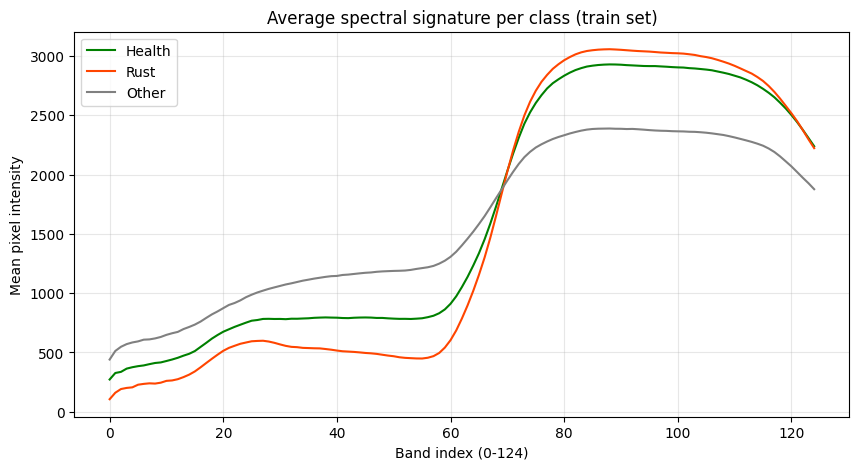

Bands where Health vs Rust differ MOST (top 10):
  band 56: Health=797.5, Rust=455.3, diff=342.3
  band 57: Health=809.7, Rust=468.8, diff=340.8
  band 55: Health=788.4, Rust=448.8, diff=339.6
  band 54: Health=784.9, Rust=449.4, diff=335.5
  band 58: Health=830.8, Rust=495.5, diff=335.3
  band 53: Health=782.4, Rust=451.8, diff=330.6
  band 52: Health=783.6, Rust=454.3, diff=329.2
  band 51: Health=783.4, Rust=459.4, diff=324.0
  band 59: Health=863.1, Rust=541.0, diff=322.1
  band 50: Health=785.2, Rust=468.0, diff=317.2

Overall mean abs difference Health-vs-Rust: 166.21
Overall mean abs difference Health-vs-Other: 368.45
Overall mean abs difference Rust-vs-Other: 534.03


In [32]:
import matplotlib.pyplot as plt
import numpy as np
import tifffile as tiff

def mean_spectrum_for_class(paths, labels, target_label, max_samples=50):
    """Average spectral signature (across all pixels, all sampled images) for one class."""
    selected = [p for p, l in zip(paths, labels) if l == target_label][:max_samples]
    band_sums = np.zeros(125, dtype=np.float64)
    pixel_count = 0
    for fp in selected:
        arr = tiff.imread(fp).astype(np.float32)
        if arr.shape[-1] == 126:
            arr = arr[:, :, :125]
        band_sums += arr.sum(axis=(0, 1))
        pixel_count += arr.shape[0] * arr.shape[1]
    return band_sums / pixel_count

health_spectrum = mean_spectrum_for_class(train_paths, train_labels, 0)
rust_spectrum   = mean_spectrum_for_class(train_paths, train_labels, 1)
other_spectrum  = mean_spectrum_for_class(train_paths, train_labels, 2)

plt.figure(figsize=(10, 5))
plt.plot(health_spectrum, label='Health', color='green')
plt.plot(rust_spectrum, label='Rust', color='orangered')
plt.plot(other_spectrum, label='Other', color='gray')
plt.xlabel('Band index (0-124)')
plt.ylabel('Mean pixel intensity')
plt.title('Average spectral signature per class (train set)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

#   numeric gap between Health and Rust specifically, band by band
diff = np.abs(health_spectrum - rust_spectrum)
print("Bands where Health vs Rust differ MOST (top 10):")
top_bands = np.argsort(diff)[::-1][:10]
for b in top_bands:
    print(f"  band {b}: Health={health_spectrum[b]:.1f}, Rust={rust_spectrum[b]:.1f}, diff={diff[b]:.1f}")

print(f"\nOverall mean abs difference Health-vs-Rust: {diff.mean():.2f}")
print(f"Overall mean abs difference Health-vs-Other: {np.abs(health_spectrum - other_spectrum).mean():.2f}")
print(f"Overall mean abs difference Rust-vs-Other: {np.abs(rust_spectrum - other_spectrum).mean():.2f}")

In [33]:

import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (
    confusion_matrix, classification_report, accuracy_score,
    precision_recall_fscore_support, roc_curve, auc, RocCurveDisplay
)
from sklearn.preprocessing import label_binarize
import seaborn as sns

CLASS_NAMES = ['Health', 'Rust', 'Other']
N_CLASSES = 3

best_ckpt = torch.load(os.path.join(CHECKPOINT_DIR, 'best_model.pt'), map_location=DEVICE)
model.load_state_dict(best_ckpt['model_state_dict'])
model.eval()

print(f"Loaded best checkpoint from epoch {best_ckpt['epoch']+1}")
print(f"Best val_loss at save time: {best_ckpt['best_val_loss']:.4f}")

Loaded best checkpoint from epoch 7
Best val_loss at save time: 0.7695


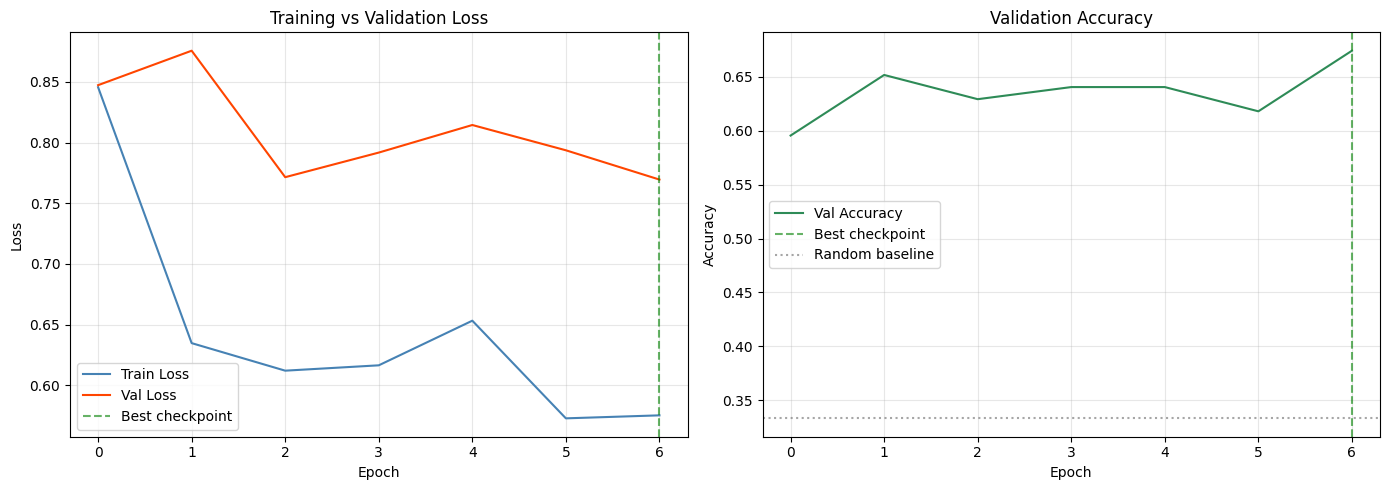

In [34]:
# ============================================================
# Training curves (loss + accuracy over epochs)
# ============================================================
history = best_ckpt['history']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history['train_loss'], label='Train Loss', color='steelblue')
axes[0].plot(history['val_loss'], label='Val Loss', color='orangered')
axes[0].axvline(best_ckpt['epoch'], color='green', linestyle='--', alpha=0.6, label='Best checkpoint')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training vs Validation Loss')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(history['val_acc'], label='Val Accuracy', color='seagreen')
axes[1].axvline(best_ckpt['epoch'], color='green', linestyle='--', alpha=0.6, label='Best checkpoint')
axes[1].axhline(1/N_CLASSES, color='gray', linestyle=':', alpha=0.7, label='Random baseline')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Validation Accuracy')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(CHECKPOINT_DIR, 'training_curves.png'), dpi=150)
plt.show()

In [35]:
# ============================================================
# C Run inference on the TEST set (only place test_loader is used)
# ============================================================
all_test_preds = []
all_test_labels = []
all_test_probs = []

model.eval()
with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(DEVICE)
        logits = model(xb)
        probs = torch.softmax(logits, dim=1)
        preds = logits.argmax(dim=1)

        all_test_preds.extend(preds.cpu().numpy())
        all_test_labels.extend(yb.numpy())
        all_test_probs.extend(probs.cpu().numpy())

all_test_preds = np.array(all_test_preds)
all_test_labels = np.array(all_test_labels)
all_test_probs = np.array(all_test_probs)  # (N, 3)

test_acc = accuracy_score(all_test_labels, all_test_preds)
print(f"\n{'='*50}")
print(f"FINAL TEST SET ACCURACY: {test_acc:.4f}")
print(f"{'='*50}\n")


FINAL TEST SET ACCURACY: 0.6292



Confusion matrix (rows=true, cols=predicted):
              Health      Rust     Other
    Health       18         8         4
      Rust       14        14         1
     Other        5         1        24


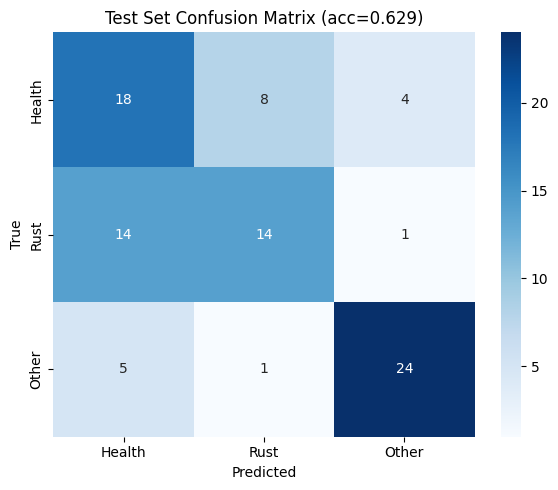

In [36]:
# ============================================================
#  Confusion matrix (numeric + heatmap)
# ============================================================
cm = confusion_matrix(all_test_labels, all_test_preds)

print("Confusion matrix (rows=true, cols=predicted):")
print("           ", "  ".join(f"{c:>8}" for c in CLASS_NAMES))
for i, row in enumerate(cm):
    print(f"{CLASS_NAMES[i]:>10}", "  ".join(f"{v:>8}" for v in row))

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax)
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
ax.set_title(f'Test Set Confusion Matrix (acc={test_acc:.3f})')
plt.tight_layout()
plt.savefig(os.path.join(CHECKPOINT_DIR, 'confusion_matrix.png'), dpi=150)
plt.show()

In [37]:
# ============================================================
#  Full classification report (precision, recall, F1 per class)
# ============================================================
report = classification_report(all_test_labels, all_test_preds,
                                  target_names=CLASS_NAMES, digits=4)
print(report)


report_dict = classification_report(all_test_labels, all_test_preds,
                                       target_names=CLASS_NAMES, output_dict=True)

with open(os.path.join(CHECKPOINT_DIR, 'test_classification_report.txt'), 'w') as f:
    f.write(f"Test Accuracy: {test_acc:.4f}\n\n")
    f.write(report)
print("\nSaved report to Drive.")

              precision    recall  f1-score   support

      Health     0.4865    0.6000    0.5373        30
        Rust     0.6087    0.4828    0.5385        29
       Other     0.8276    0.8000    0.8136        30

    accuracy                         0.6292        89
   macro avg     0.6409    0.6276    0.6298        89
weighted avg     0.6413    0.6292    0.6308        89


Saved report to Drive.


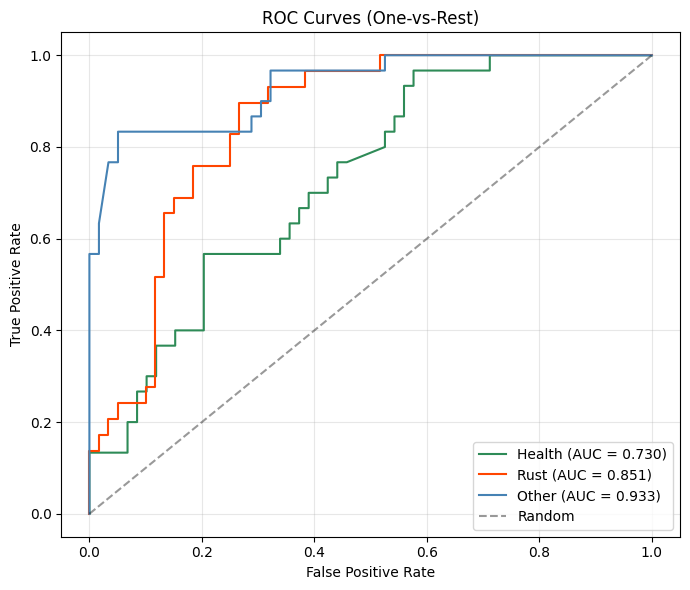

In [38]:
# ============================================================
#  ROC curves + AUC per class (one-vs-rest, standard for multiclass)
# ============================================================
labels_binarized = label_binarize(all_test_labels, classes=[0, 1, 2])  # (N, 3)

fig, ax = plt.subplots(figsize=(7, 6))
colors = ['seagreen', 'orangered', 'steelblue']

for i, (cls_name, color) in enumerate(zip(CLASS_NAMES, colors)):
    fpr, tpr, _ = roc_curve(labels_binarized[:, i], all_test_probs[:, i])
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=color, label=f'{cls_name} (AUC = {roc_auc:.3f})')

ax.plot([0, 1], [0, 1], 'k--', alpha=0.4, label='Random')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves (One-vs-Rest)')
ax.legend(loc='lower right')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(CHECKPOINT_DIR, 'roc_curves.png'), dpi=150)
plt.show()

In [42]:
# ============================================================
#  Reusable detailed prediction visualizer
# (image + true/pred labels + full probability bars)
# ============================================================
def visualize_predictions(indices, title, save_name):
    n = len(indices)
    n_cols = 4
    n_rows = int(np.ceil(n / n_cols))

    fig, axes = plt.subplots(n_rows * 2, n_cols, figsize=(4 * n_cols, 3.5 * n_rows * 2),
                               gridspec_kw={'height_ratios': [3, 1] * n_rows})
    if n_rows == 1:
        axes = axes.reshape(2, n_cols)

    for i, idx in enumerate(indices):
        row_img = (i // n_cols) * 2
        row_bar = row_img + 1
        col = i % n_cols

        filepath = test_paths[idx]
        arr = load_and_clean(filepath)
        r_band, g_band, b_band = 90, 50, 10
        rgb_approx = arr[:, :, [r_band, g_band, b_band]]
        rgb_norm = (rgb_approx - rgb_approx.min()) / (rgb_approx.max() - rgb_approx.min() + 1e-8)

        true_cls = CLASS_NAMES[all_test_labels[idx]]
        pred_cls = CLASS_NAMES[all_test_preds[idx]]
        probs = all_test_probs[idx]
        is_correct = all_test_labels[idx] == all_test_preds[idx]
        title_color = 'seagreen' if is_correct else 'orangered'

        ax_img = axes[row_img, col]
        ax_img.imshow(rgb_norm)
        ax_img.set_title(f"True: {true_cls} | Pred: {pred_cls}\nConfidence: {probs.max():.2%}",
                          fontsize=10, color=title_color)
        ax_img.axis('off')

        ax_bar = axes[row_bar, col]
        bar_colors = ['seagreen' if j == all_test_labels[idx] else 'lightgray' for j in range(N_CLASSES)]
        ax_bar.bar(CLASS_NAMES, probs, color=bar_colors, edgecolor='black', linewidth=0.5)
        ax_bar.set_ylim(0, 1)
        ax_bar.tick_params(axis='x', labelsize=8)
        ax_bar.tick_params(axis='y', labelsize=8)


    total_slots = n_rows * n_cols
    for i in range(n, total_slots):
        row_img = (i // n_cols) * 2
        col = i % n_cols
        axes[row_img, col].axis('off')
        axes[row_img + 1, col].axis('off')

    plt.suptitle(title, fontsize=14, y=1.0)
    plt.tight_layout()
    plt.savefig(os.path.join(CHECKPOINT_DIR, save_name), dpi=150, bbox_inches='tight')
    plt.show()

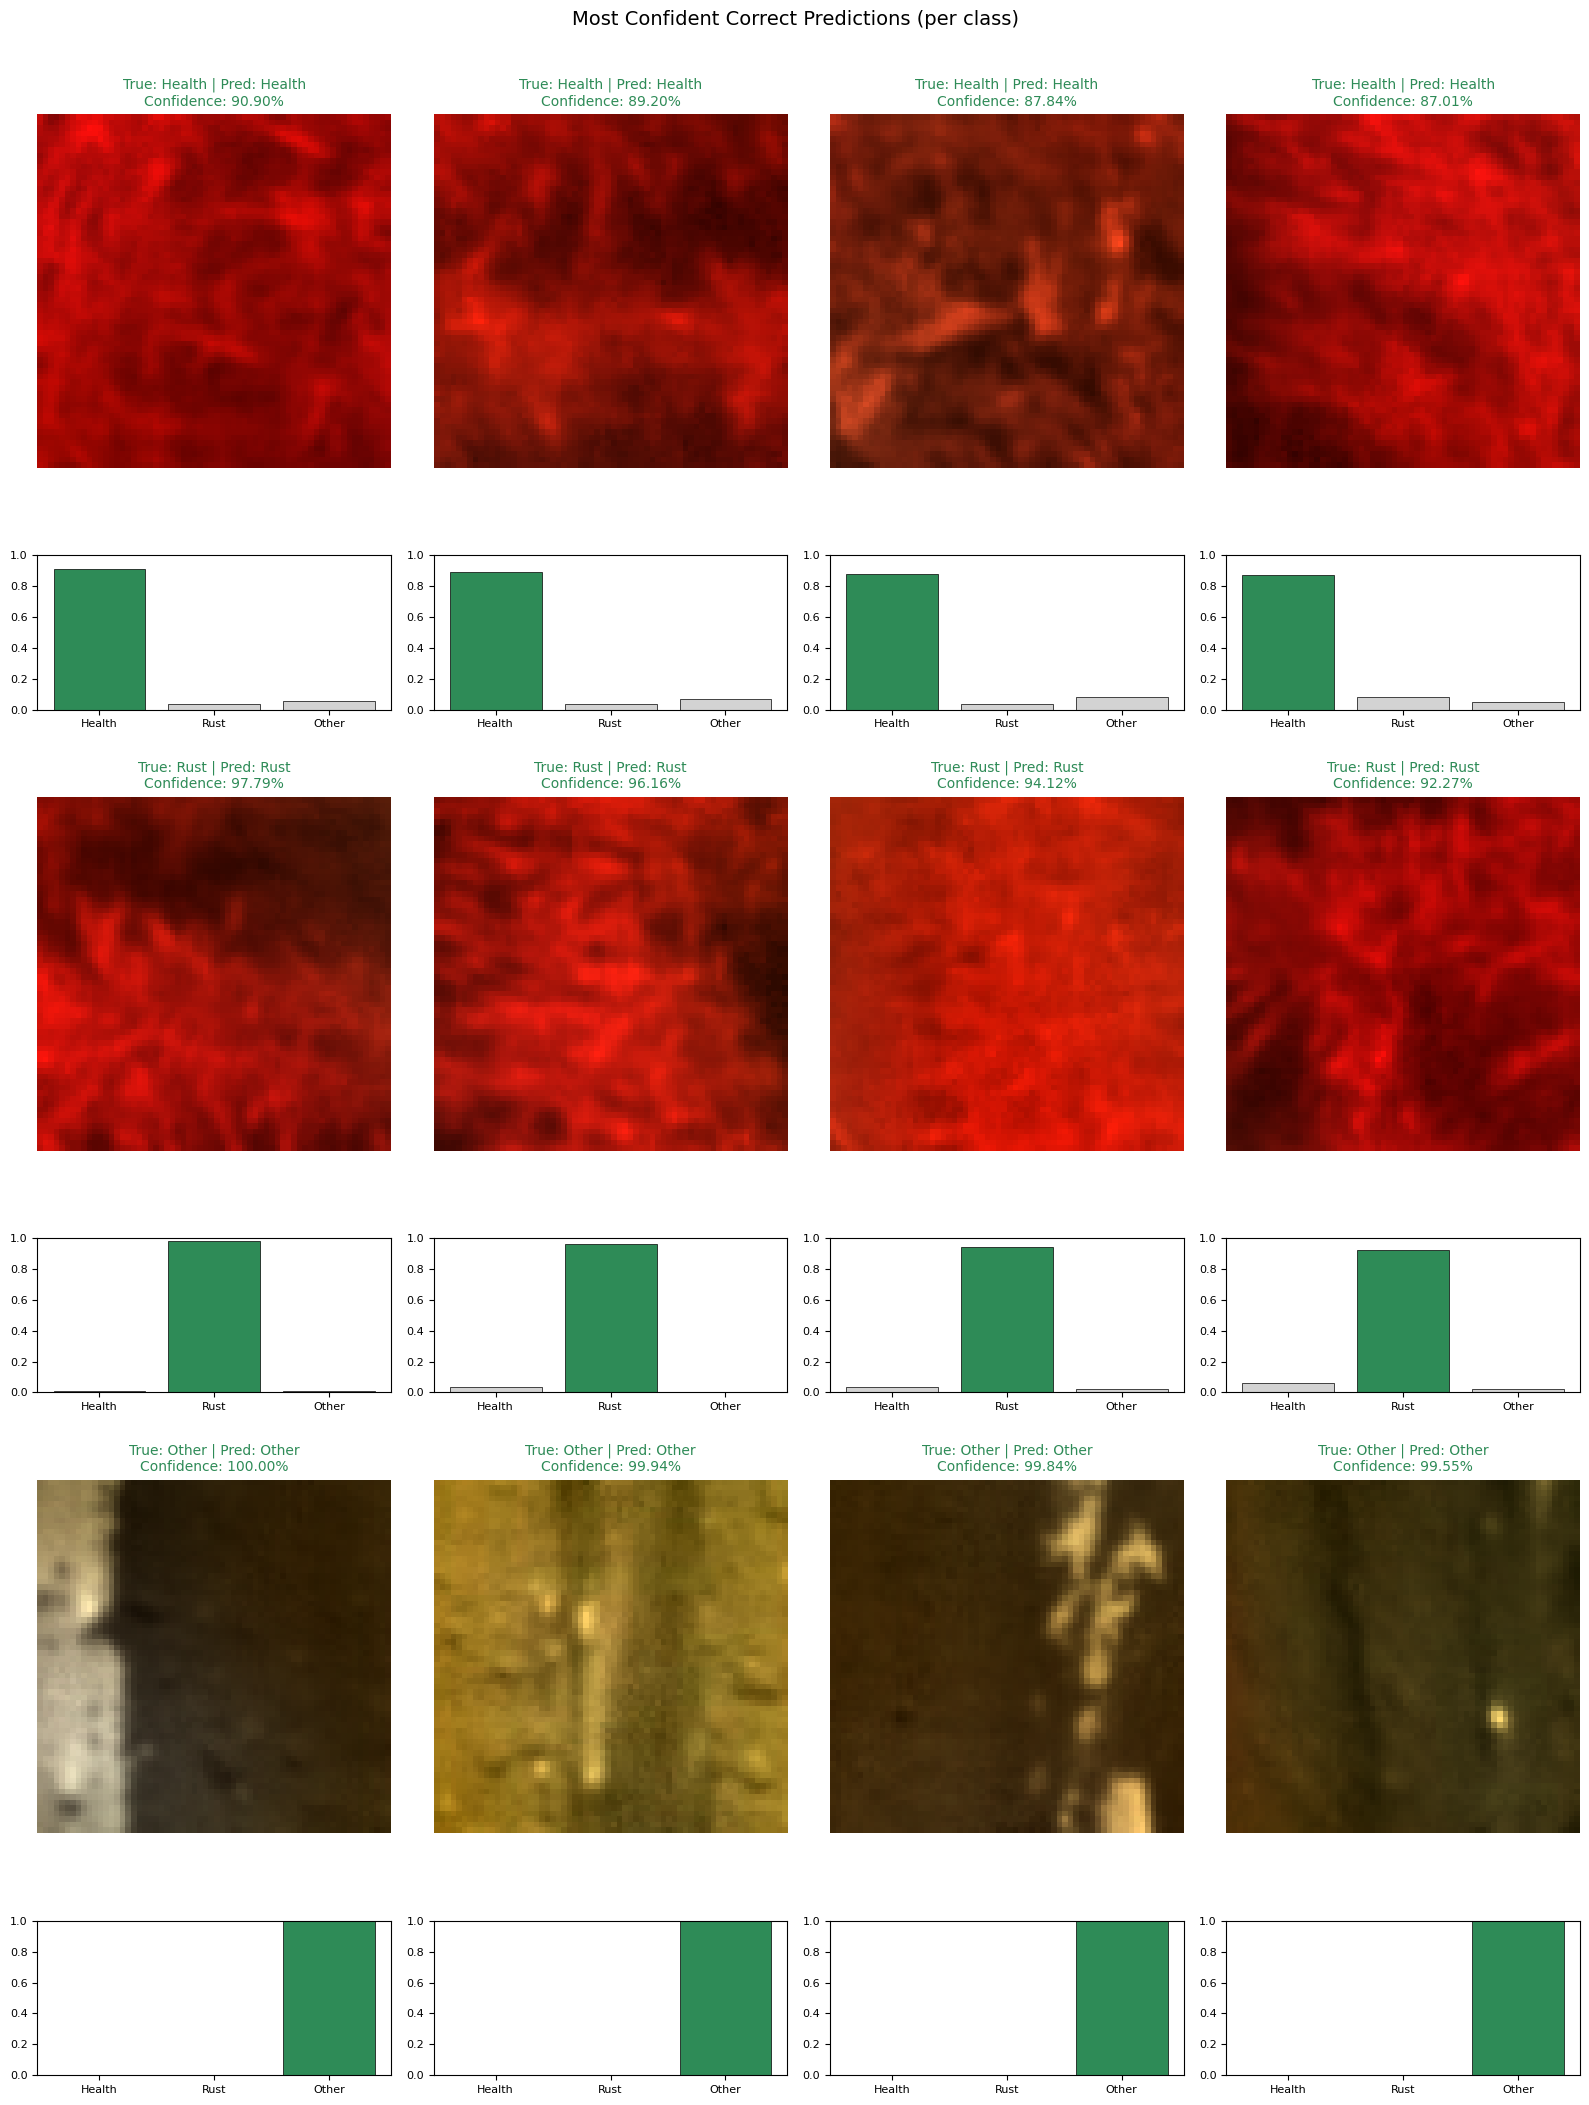

In [43]:
# ============================================================
#  CORRECT ones, one per class
# ============================================================
correct_mask = all_test_preds == all_test_labels
confidence = all_test_probs.max(axis=1)

best_indices = []
for cls_idx in range(N_CLASSES):
    cls_mask = (all_test_labels == cls_idx) & correct_mask
    cls_indices = np.where(cls_mask)[0]
    if len(cls_indices) > 0:

        cls_conf = confidence[cls_indices]
        top4 = cls_indices[np.argsort(cls_conf)[::-1][:4]]
        best_indices.extend(top4.tolist())

visualize_predictions(
    best_indices,
    title="Most Confident Correct Predictions (per class)",
    save_name="best_predictions.png"
)

Total misclassified: 33 / 89


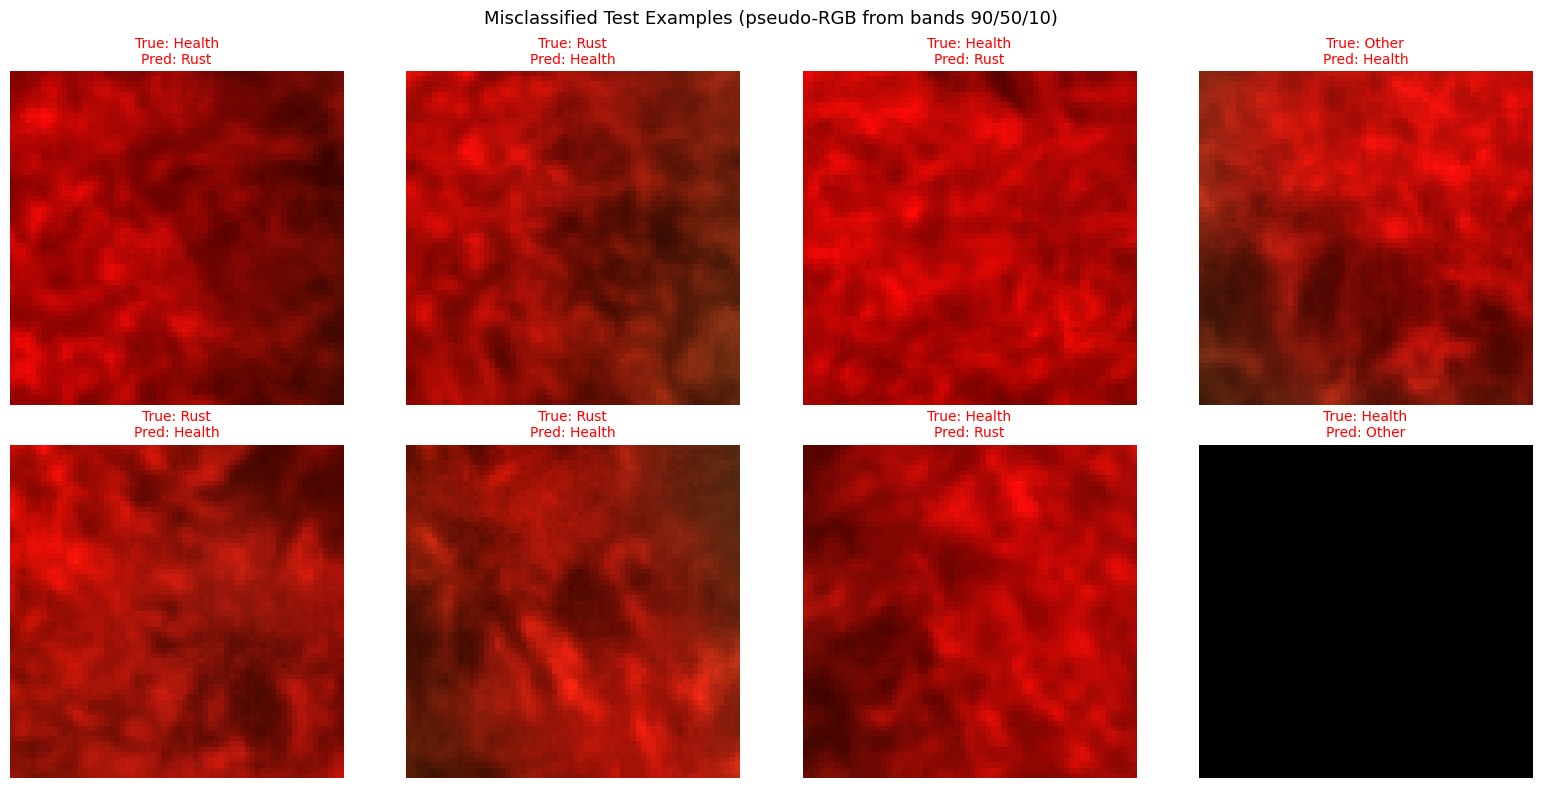

In [39]:
# ============================================================
#  Visualize misclassified examples
# ============================================================
misclassified_idx = np.where(all_test_preds != all_test_labels)[0]
print(f"Total misclassified: {len(misclassified_idx)} / {len(all_test_labels)}")

#  original RGB-ish preview using 3 raw bands
n_show = min(8, len(misclassified_idx))
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, idx in enumerate(misclassified_idx[:n_show]):
    filepath = test_paths[idx]
    arr = load_and_clean(filepath)  # (64, 64, 125)

    # Approximate a viewable RGB using 3 representative bands (not true color,

    r_band, g_band, b_band = 90, 50, 10
    rgb_approx = arr[:, :, [r_band, g_band, b_band]]
    rgb_norm = (rgb_approx - rgb_approx.min()) / (rgb_approx.max() - rgb_approx.min() + 1e-8)

    axes[i].imshow(rgb_norm)
    true_cls = CLASS_NAMES[all_test_labels[idx]]
    pred_cls = CLASS_NAMES[all_test_preds[idx]]
    axes[i].set_title(f"True: {true_cls}\nPred: {pred_cls}", fontsize=10, color='red')
    axes[i].axis('off')

for j in range(n_show, len(axes)):
    axes[j].axis('off')

plt.suptitle('Misclassified Test Examples (pseudo-RGB from bands 90/50/10)', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(CHECKPOINT_DIR, 'misclassified_examples.png'), dpi=150)
plt.show()

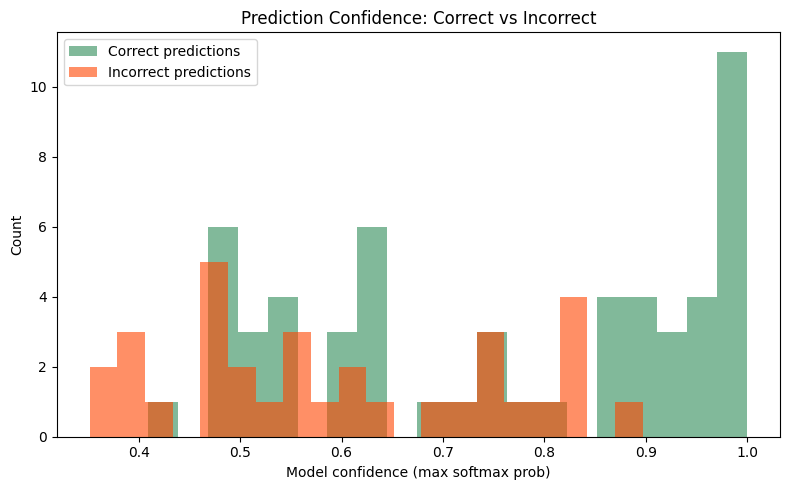

Mean confidence when correct: 0.755
Mean confidence when incorrect: 0.601


In [40]:
# ============================================================
# Per-class prediction confidence distribution
#
# ============================================================
correct_mask = all_test_preds == all_test_labels
confidence = all_test_probs.max(axis=1)  # model's confidence in its top prediction

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(confidence[correct_mask], bins=20, alpha=0.6, label='Correct predictions', color='seagreen')
ax.hist(confidence[~correct_mask], bins=20, alpha=0.6, label='Incorrect predictions', color='orangered')
ax.set_xlabel('Model confidence (max softmax prob)')
ax.set_ylabel('Count')
ax.set_title('Prediction Confidence: Correct vs Incorrect')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(CHECKPOINT_DIR, 'confidence_distribution.png'), dpi=150)
plt.show()

print(f"Mean confidence when correct: {confidence[correct_mask].mean():.3f}")
print(f"Mean confidence when incorrect: {confidence[~correct_mask].mean():.3f}")

In [41]:

# ============================================================
import json

summary = {
    'test_accuracy': float(test_acc),
    'best_epoch': int(best_ckpt['epoch'] + 1),
    'best_val_loss': float(best_ckpt['best_val_loss']),
    'per_class_metrics': report_dict,
    'confusion_matrix': cm.tolist(),
    'n_test_samples': len(all_test_labels),
    'model_architecture': 'PhytoGuardCNN2D (LDA+PCA features, 7 channels)',
    'n_pca_components': N_PCA_COMPONENTS,
}

with open(os.path.join(CHECKPOINT_DIR, 'final_results_summary.json'), 'w') as f:
    json.dump(summary, f, indent=2)

print("Saved final_results_summary.json to Drive.")
print(json.dumps(summary, indent=2))

Saved final_results_summary.json to Drive.
{
  "test_accuracy": 0.6292134831460674,
  "best_epoch": 7,
  "best_val_loss": 0.7694981111569351,
  "per_class_metrics": {
    "Health": {
      "precision": 0.4864864864864865,
      "recall": 0.6,
      "f1-score": 0.5373134328358209,
      "support": 30.0
    },
    "Rust": {
      "precision": 0.6086956521739131,
      "recall": 0.4827586206896552,
      "f1-score": 0.5384615384615384,
      "support": 29.0
    },
    "Other": {
      "precision": 0.8275862068965517,
      "recall": 0.8,
      "f1-score": 0.8135593220338984,
      "support": 30.0
    },
    "accuracy": 0.6292134831460674,
    "macro avg": {
      "precision": 0.640922781852317,
      "recall": 0.6275862068965518,
      "f1-score": 0.6297780977770859,
      "support": 89.0
    },
    "weighted avg": {
      "precision": 0.6412848844329733,
      "recall": 0.6292134831460674,
      "f1-score": 0.6308041265334404,
      "support": 89.0
    }
  },
  "confusion_matrix": [
    